# TrashTrack — ML Report
## Smart City Waste Management Platform — Kelompok 6

**Laporan ini mencakup:**
1. Deskripsi Dataset & Data Generation
2. Exploratory Data Analysis (EDA)
3. Model 1 — Fill Rate Predictor (Regresi)
4. Model 2 — Pickup Priority Classifier (Klasifikasi Multi-Kelas)
5. Model 3 — Anomaly Detector (Klasifikasi Biner)
6. Ringkasan Performa

---
> **Cara menjalankan notebook ini:**  
> Dari folder `python-ml-service/`, jalankan semua cell secara berurutan.  
> Model dan data akan dibuat otomatis jika belum ada.

## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully.')
print(f'Pandas   : {pd.__version__}')
print(f'NumPy    : {np.__version__}')
print(f'Seaborn  : {sns.__version__}')

Libraries loaded successfully.
Pandas   : 3.0.3
NumPy    : 2.4.6
Seaborn  : 0.13.2


---
## 1. Dataset — Synthetic Data Generation

Dataset dihasilkan secara sintetis menggunakan `generate_data.py` yang mensimulasikan **1.000.000 pembacaan sensor** tong sampah pintar di kota Jakarta.

### Sumber Fitur
| Fitur | Tipe | Keterangan |
|-------|------|------------|
| `jam` | int | Jam saat ini (0–23) |
| `suhu_cuaca` | float | Suhu lingkungan (25–38°C) |
| `volume_sekarang` | float | Persentase kepenuhan tong (0–100%) |
| `latitude` | float | Koordinat GPS lintang |
| `longitude` | float | Koordinat GPS bujur |
| `is_weekend` | int | 1 = Sabtu/Minggu, 0 = hari kerja |
| `kadar_metana` | float | Kadar gas metana sensor MQ-2 (0–50 ppm) |
| `laporan_warga` | int | Jumlah laporan warga (0–10) |
| `jarak_ultrasonik` | float | Jarak sensor HC-SR04 ke sampah (cm) |
| `delta_volume_sec` | float | Perubahan volume per detik |

### Target Variable
| Target | Model | Tipe |
|--------|-------|------|
| `jam_sampai_penuh` | Fill Rate | Regresi (jam) |
| `pickup_priority` | Priority | Klasifikasi (Low/Medium/Urgent/Critical) |
| `is_anomaly` | Anomaly | Klasifikasi biner (0/1) |

In [2]:
# Generate data jika belum ada
data_path = Path('./data/trash_data.csv')
if not data_path.exists():
    print('Data belum ada, generating...')
    import generate_data
    generate_data.generate_synthetic_data()
else:
    print(f'Data ditemukan: {data_path}')

df = pd.read_csv(data_path)
print(f'Shape   : {df.shape}')
print(f'Kolom   : {list(df.columns)}')

Data ditemukan: data\trash_data.csv
Shape   : (1000000, 13)
Kolom   : ['jam', 'suhu_cuaca', 'volume_sekarang', 'latitude', 'longitude', 'is_weekend', 'kadar_metana', 'laporan_warga', 'jarak_ultrasonik', 'delta_volume_sec', 'jam_sampai_penuh', 'pickup_priority', 'is_anomaly']


In [3]:
df.head(10)

,jam,suhu_cuaca,volume_sekarang,latitude,longitude,is_weekend,kadar_metana,laporan_warga,jarak_ultrasonik,delta_volume_sec,jam_sampai_penuh,pickup_priority,is_anomaly
0,6,37.091130,32.358607,-6.194795,106.831170,0,7.818528,6,69.720552,-1.394614,32.324627,Medium,1
1,19,26.499367,71.588510,-6.206406,106.953407,0,32.612364,0,26.339347,-0.817988,8.775412,Urgent,0
2,14,28.818592,86.398276,-6.232691,106.810816,0,27.491470,6,13.482528,-1.401003,4.128476,Critical,0
3,10,30.285911,42.154571,-6.125126,106.808678,0,19.697333,5,56.269083,-0.093172,9.051895,Medium,0
4,7,26.030797,12.044983,-6.195013,106.846854,0,45.877705,2,84.849175,-0.627422,41.070005,Medium,0
5,20,28.697773,14.025401,-6.207479,106.955142,0,20.265182,4,82.960999,0.327584,41.792777,Medium,0
6,6,34.530033,23.672425,-6.228236,106.793281,0,48.859642,9,77.694488,0.313877,20.490821,Urgent,0
7,18,35.956027,28.349332,-6.126992,106.807483,0,18.357344,3,70.434742,-0.299643,17.540251,Medium,0
8,22,30.565952,85.564106,-6.125200,106.813930,0,10.401132,5,14.124012,0.465566,3.024866,Urgent,0
9,10,30.258842,15.837852,-6.203521,106.951159,1,16.417507,4,80.449028,0.415454,9.707590,Medium,0


In [4]:
print('=== Info Dataset ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   jam               1000000 non-null  int64  
 1   suhu_cuaca        1000000 non-null  float64
 2   volume_sekarang   1000000 non-null  float64
 3   latitude          1000000 non-null  float64
 4   longitude         1000000 non-null  float64
 5   is_weekend        1000000 non-null  int64  
 6   kadar_metana      1000000 non-null  float64
 7   laporan_warga     1000000 non-null  int64  
 8   jarak_ultrasonik  1000000 non-null  float64
 9   delta_volume_sec  1000000 non-null  float64
 10  jam_sampai_penuh  1000000 non-null  float64
 11  pickup_priority   1000000 non-null  str    
 12  is_anomaly        1000000 non-null  int64  
dtypes: float64(8), int64(4), str(1)
memory usage: 99.2 MB

=== Missing Values ===
jam                 0
suhu_cuaca          0
volume_sekarang 

In [5]:
df.describe().round(3)

,jam,suhu_cuaca,volume_sekarang,latitude,longitude,is_weekend,kadar_metana,laporan_warga,jarak_ultrasonik,delta_volume_sec,jam_sampai_penuh,is_anomaly
count,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000
mean,11.495,31.501,49.987,-6.187,106.838,0.300,25.007,4.504,50.011,-0.075,14.825,0.124
std,6.922,3.753,28.871,0.041,0.065,0.458,14.451,2.874,28.940,0.908,12.144,0.330
min,0.000,25.000,0.000,-6.259,106.717,0.000,0.000,0.000,-8.058,-10.000,0.100,0.000
25%,5.000,28.249,24.996,-6.207,106.802,0.000,12.496,2.000,25.008,-0.349,5.285,0.000
50%,12.000,31.504,49.989,-6.196,106.816,0.000,25.011,5.000,50.026,-0.006,11.341,0.000
75%,17.000,34.750,74.979,-6.151,106.838,1.000,37.531,7.000,75.011,0.332,21.673,0.000
max,23.000,38.000,100.000,-6.099,106.976,1.000,50.000,9.000,107.088,2.542,52.999,1.000


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Distribusi Fitur Numerik

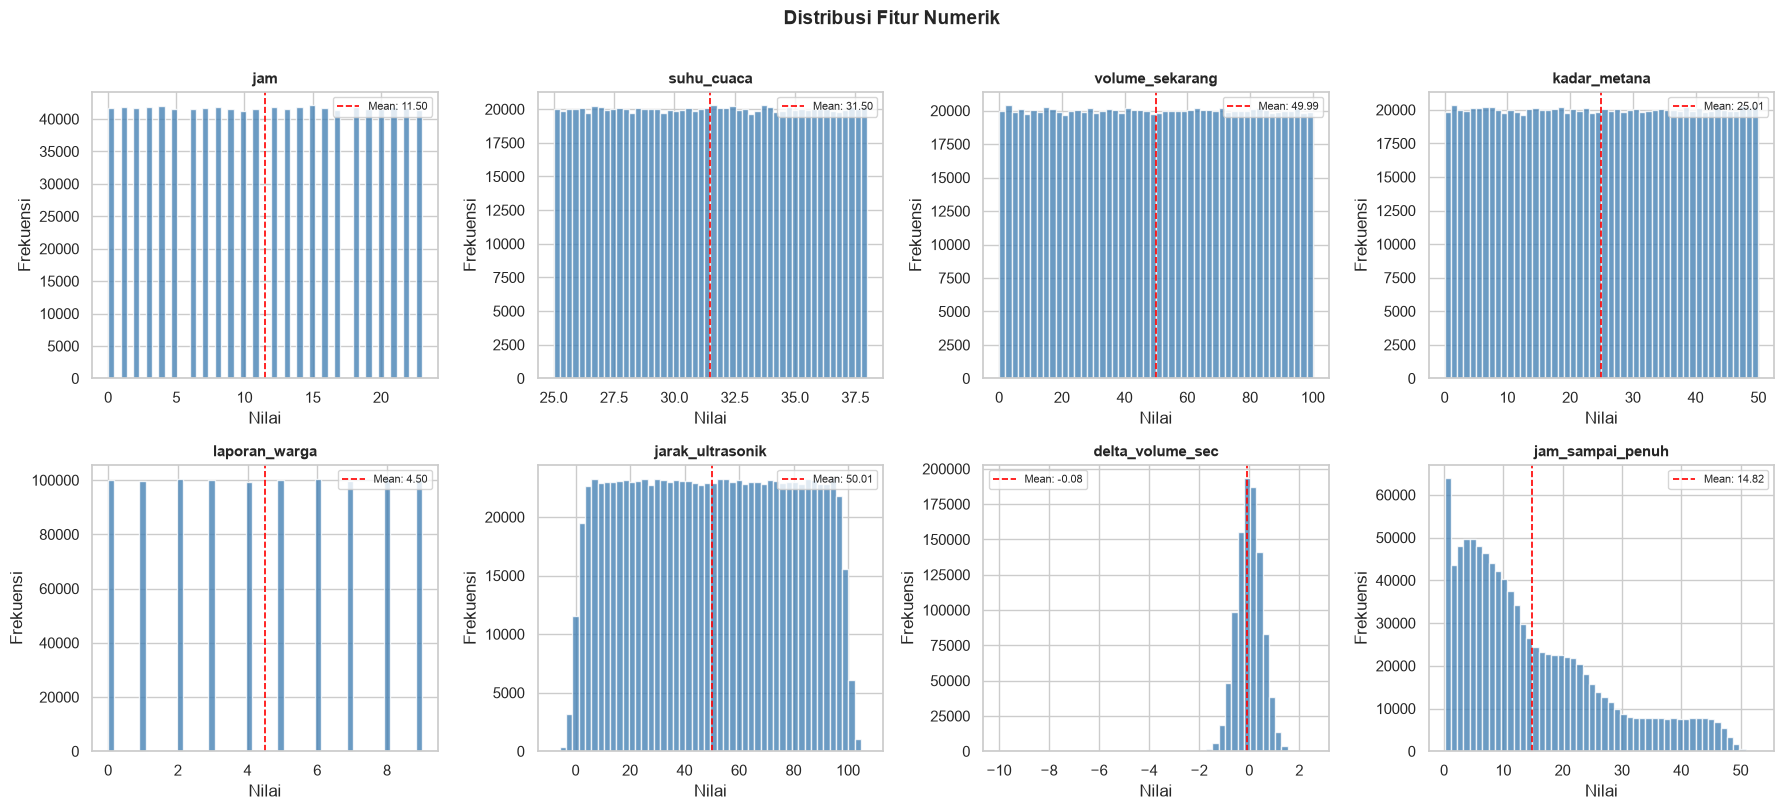

In [6]:
num_features = ['jam', 'suhu_cuaca', 'volume_sekarang', 'kadar_metana',
                'laporan_warga', 'jarak_ultrasonik', 'delta_volume_sec', 'jam_sampai_penuh']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean: {df[col].mean():.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Distribusi Target Variables

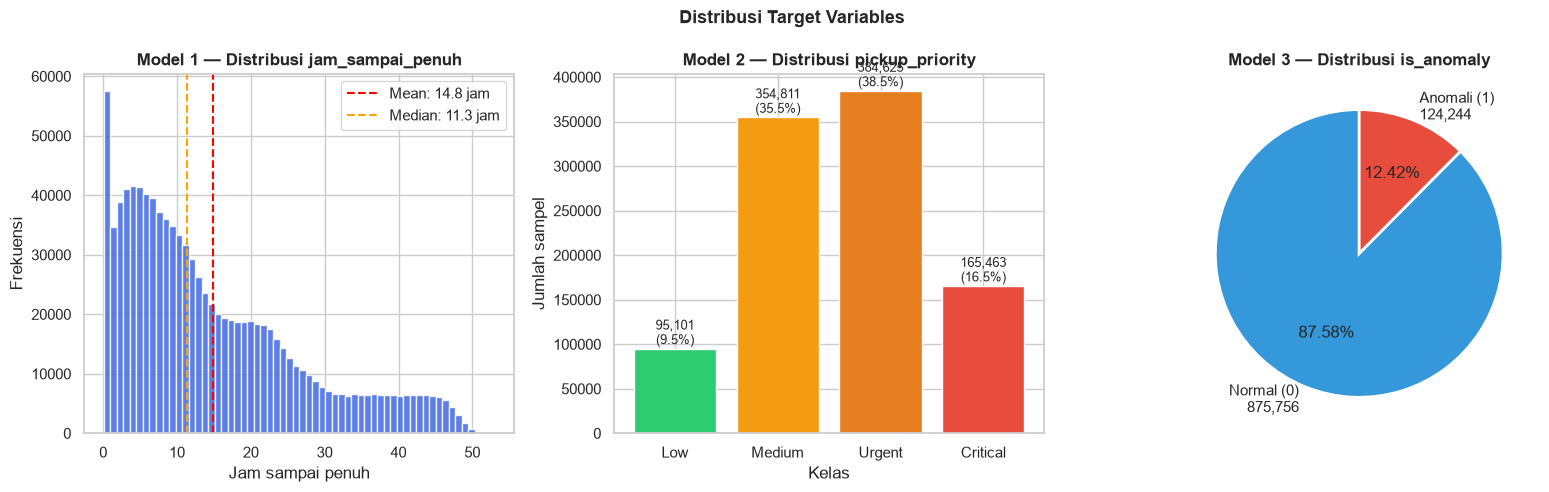


Priority distribution:
pickup_priority
Urgent      384625
Medium      354811
Critical    165463
Low          95101
Name: count, dtype: int64

Anomaly distribution:
is_anomaly
0    875756
1    124244
Name: count, dtype: int64
  Rasio anomali: 12.42%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Target 1: jam_sampai_penuh
axes[0].hist(df['jam_sampai_penuh'], bins=60, color='royalblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Model 1 — Distribusi jam_sampai_penuh', fontweight='bold')
axes[0].set_xlabel('Jam sampai penuh')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['jam_sampai_penuh'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['jam_sampai_penuh'].mean():.1f} jam")
axes[0].axvline(df['jam_sampai_penuh'].median(), color='orange', linestyle='--',
                label=f"Median: {df['jam_sampai_penuh'].median():.1f} jam")
axes[0].legend()

# Target 2: pickup_priority
priority_order = ['Low', 'Medium', 'Urgent', 'Critical']
priority_counts = df['pickup_priority'].value_counts().reindex(priority_order)
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
bars = axes[1].bar(priority_counts.index, priority_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Model 2 — Distribusi pickup_priority', fontweight='bold')
axes[1].set_xlabel('Kelas')
axes[1].set_ylabel('Jumlah sampel')
for bar, val in zip(bars, priority_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Target 3: is_anomaly
anomaly_counts = df['is_anomaly'].value_counts().sort_index()
labels = [f'Normal (0)\n{anomaly_counts[0]:,}', f'Anomali (1)\n{anomaly_counts[1]:,}']
axes[2].pie(anomaly_counts.values, labels=labels, colors=['#3498db', '#e74c3c'],
            autopct='%1.2f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('Model 3 — Distribusi is_anomaly', fontweight='bold')

plt.suptitle('Distribusi Target Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nPriority distribution:")
print(df['pickup_priority'].value_counts())
print(f"\nAnomaly distribution:")
print(df['is_anomaly'].value_counts())
print(f"  Rasio anomali: {df['is_anomaly'].mean()*100:.2f}%")

### 2.3 Matriks Korelasi

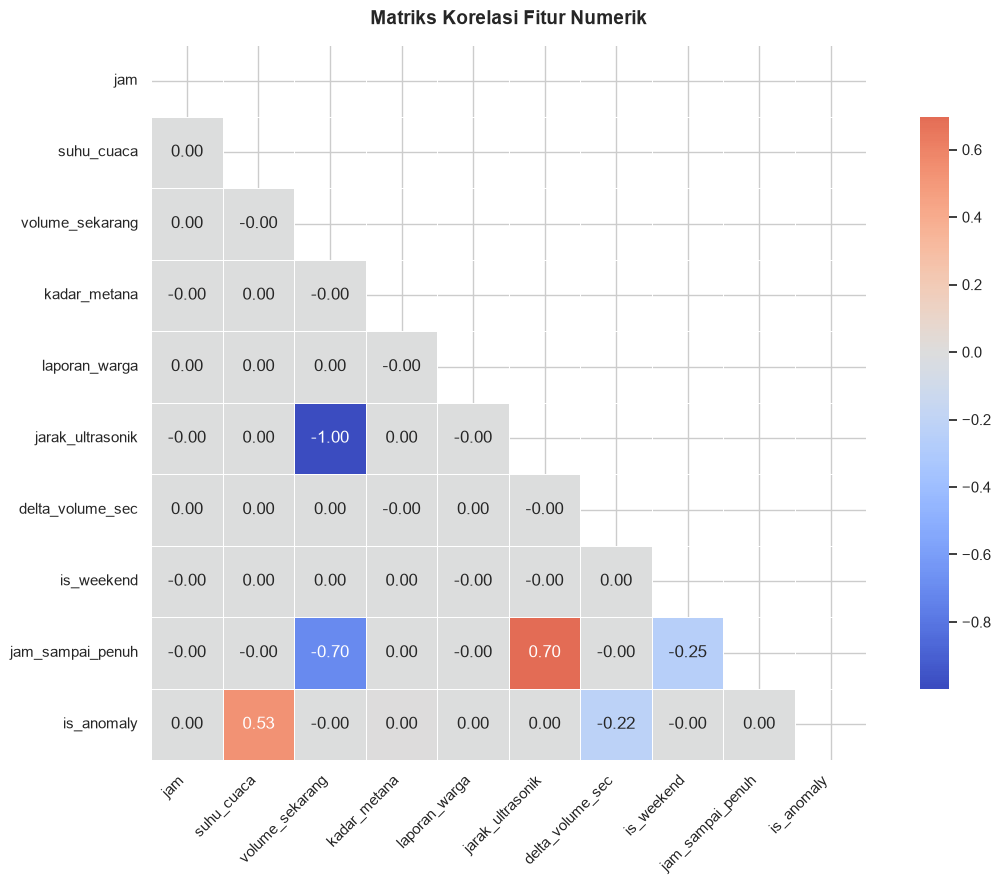


Korelasi tertinggi terhadap jam_sampai_penuh:
volume_sekarang     0.699613
jarak_ultrasonik    0.697958
is_weekend          0.253481
delta_volume_sec    0.001691
jam                 0.001517
kadar_metana        0.000938
Name: jam_sampai_penuh, dtype: float64

Korelasi tertinggi terhadap is_anomaly:
suhu_cuaca          0.530806
delta_volume_sec    0.219025
kadar_metana        0.003317
volume_sekarang     0.002085
jarak_ultrasonik    0.002074
jam_sampai_penuh    0.000849
Name: is_anomaly, dtype: float64


In [8]:
num_cols = ['jam', 'suhu_cuaca', 'volume_sekarang', 'kadar_metana',
            'laporan_warga', 'jarak_ultrasonik', 'delta_volume_sec',
            'is_weekend', 'jam_sampai_penuh', 'is_anomaly']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nKorelasi tertinggi terhadap jam_sampai_penuh:")
print(corr_matrix['jam_sampai_penuh'].drop('jam_sampai_penuh').abs().sort_values(ascending=False).head(6))
print("\nKorelasi tertinggi terhadap is_anomaly:")
print(corr_matrix['is_anomaly'].drop('is_anomaly').abs().sort_values(ascending=False).head(6))

### 2.4 Analisis Fitur vs Target

ValueError: The palette dictionary is missing keys: {'1', '0'}

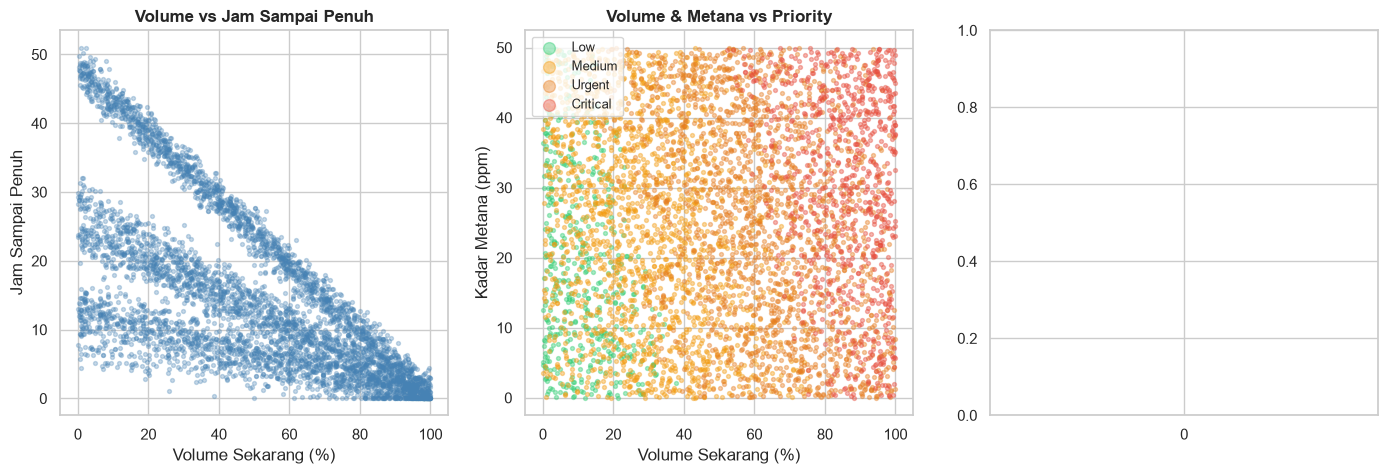

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# volume_sekarang vs jam_sampai_penuh
sample = df.sample(5000, random_state=42)
axes[0].scatter(sample['volume_sekarang'], sample['jam_sampai_penuh'],
                alpha=0.3, s=8, color='steelblue')
axes[0].set_xlabel('Volume Sekarang (%)')
axes[0].set_ylabel('Jam Sampai Penuh')
axes[0].set_title('Volume vs Jam Sampai Penuh', fontweight='bold')

# volume + metana vs priority
priority_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'Urgent': '#e67e22', 'Critical': '#e74c3c'}
for p, color in priority_colors.items():
    mask = sample['pickup_priority'] == p
    axes[1].scatter(sample.loc[mask, 'volume_sekarang'],
                    sample.loc[mask, 'kadar_metana'],
                    alpha=0.4, s=8, color=color, label=p)
axes[1].set_xlabel('Volume Sekarang (%)')
axes[1].set_ylabel('Kadar Metana (ppm)')
axes[1].set_title('Volume & Metana vs Priority', fontweight='bold')
axes[1].legend(markerscale=3, fontsize=9)

# suhu vs is_anomaly
sns.boxplot(data=df, x='is_anomaly', y='suhu_cuaca', ax=axes[2],
            palette={0: '#3498db', 1: '#e74c3c'})
axes[2].set_xticklabels(['Normal (0)', 'Anomali (1)'])
axes[2].set_xlabel('Status')
axes[2].set_ylabel('Suhu Cuaca (°C)')
axes[2].set_title('Distribusi Suhu per Kelas Anomali', fontweight='bold')
axes[2].axhline(36.5, color='red', linestyle='--', linewidth=1.2, label='Threshold 36.5°C')
axes[2].legend()

plt.suptitle('Analisis Hubungan Fitur vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jam vs jam_sampai_penuh
jam_avg = df.groupby('jam')['jam_sampai_penuh'].mean()
axes[0].plot(jam_avg.index, jam_avg.values, marker='o', color='royalblue', linewidth=2)
axes[0].fill_between(jam_avg.index, jam_avg.values, alpha=0.2, color='royalblue')
axes[0].set_xlabel('Jam (0–23)')
axes[0].set_ylabel('Rata-rata Jam Sampai Penuh')
axes[0].set_title('Pola Harian: Jam vs Jam Sampai Penuh', fontweight='bold')
axes[0].set_xticks(range(0, 24, 2))

# Weekend vs priority
weekend_priority = df.groupby(['is_weekend', 'pickup_priority']).size().unstack(fill_value=0)
weekend_priority = weekend_priority.div(weekend_priority.sum(axis=1), axis=0) * 100
weekend_priority.index = ['Weekday', 'Weekend']
weekend_priority[['Low','Medium','Urgent','Critical']].plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#f39c12','#e67e22','#e74c3c'],
    edgecolor='white', width=0.6
)
axes[1].set_title('Distribusi Priority: Weekday vs Weekend', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Persentase (%)')
axes[1].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
axes[1].legend(title='Priority', bbox_to_anchor=(1.02, 1))

plt.suptitle('Analisis Temporal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Model 1 — Fill Rate Predictor

**Tujuan:** Memprediksi berapa jam lagi tong sampah akan penuh.

**Algoritma:** Random Forest Regressor  
**Fitur input:** `jam`, `suhu_cuaca`, `volume_sekarang`, `latitude`, `longitude`, `is_weekend`  
**Target:** `jam_sampai_penuh`  
**Pipeline:** StandardScaler → RandomForestRegressor(n_estimators=100, max_depth=10)

In [ ]:
# Persiapan data Model 1
features_m1 = ['jam', 'suhu_cuaca', 'volume_sekarang', 'latitude', 'longitude', 'is_weekend']
X1 = df[features_m1]
y1 = df['jam_sampai_penuh']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

print(f'Total samples : {len(df):,}')
print(f'Train samples : {len(X1_train):,} (80%)')
print(f'Test samples  : {len(X1_test):,} (20%)')
print(f'\nTarget statistics:')
print(y1.describe().round(3))

In [ ]:
model_path_m1 = Path('./models/fill_rate_model.pkl')
Path('./models').mkdir(exist_ok=True)

if model_path_m1.exists():
    print('Model sudah ada, loading...')
    pipeline_m1 = joblib.load(model_path_m1)
else:
    print('Training Model 1 (Fill Rate)...')
    pipeline_m1 = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(n_estimators=100, max_depth=10,
                                             random_state=42, n_jobs=-1))
    ])
    pipeline_m1.fit(X1_train, y1_train)
    joblib.dump(pipeline_m1, model_path_m1)
    print(f'Model saved to {model_path_m1}')

y1_pred = pipeline_m1.predict(X1_test)
mae1    = mean_absolute_error(y1_test, y1_pred)
r2_1    = r2_score(y1_test, y1_pred)

print(f'\n=== Evaluasi Model 1 — Fill Rate ===')
print(f'  MAE (Mean Absolute Error) : {mae1:.4f} jam')
print(f'  R² Score                  : {r2_1:.4f}')
print(f'  Interpretasi MAE          : prediksi rata-rata meleset ±{mae1:.2f} jam dari aktual')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted vs Actual
sample_idx = np.random.choice(len(y1_test), 3000, replace=False)
y1_test_arr = np.array(y1_test)
axes[0].scatter(y1_test_arr[sample_idx], y1_pred[sample_idx],
                alpha=0.3, s=8, color='steelblue')
lim_min = min(y1_test_arr.min(), y1_pred.min())
lim_max = max(y1_test_arr.max(), y1_pred.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Aktual (jam)')
axes[0].set_ylabel('Prediksi (jam)')
axes[0].set_title(f'Predicted vs Actual\nMAE={mae1:.3f} | R²={r2_1:.3f}', fontweight='bold')
axes[0].legend()

# Plot 2: Residual Distribution
residuals = y1_pred - y1_test_arr
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(residuals.mean(), color='red', linestyle=':', linewidth=1.5,
                label=f'Mean residual: {residuals.mean():.3f}')
axes[1].set_xlabel('Residual (Prediksi − Aktual)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual', fontweight='bold')
axes[1].legend()

# Plot 3: Feature Importance
rf_m1 = pipeline_m1.named_steps['regressor']
importances_m1 = pd.Series(rf_m1.feature_importances_, index=features_m1).sort_values()
importances_m1.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')
for i, v in enumerate(importances_m1):
    axes[2].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Model 1 — Fill Rate Predictor (Random Forest Regressor)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFeature Importance (urut dari tertinggi):')
print(importances_m1.sort_values(ascending=False).to_string())

---
## 4. Model 2 — Pickup Priority Classifier

**Tujuan:** Mengklasifikasikan tingkat prioritas pengangkutan sampah.

**Algoritma:** Gradient Boosting Classifier  
**Fitur input:** `volume_sekarang`, `kadar_metana`, `laporan_warga`  
**Target:** `pickup_priority` — 4 kelas: Low / Medium / Urgent / Critical  
**Pipeline:** StandardScaler → GradientBoostingClassifier(n_estimators=100, lr=0.1)

In [ ]:
features_m2 = ['volume_sekarang', 'kadar_metana', 'laporan_warga']
X2 = df[features_m2]
y2 = df['pickup_priority']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

print('Distribusi kelas pada data training:')
print(y2_train.value_counts())
print('\nDistribusi kelas pada data test:')
print(y2_test.value_counts())

In [ ]:
model_path_m2 = Path('./models/priority_model.pkl')

if model_path_m2.exists():
    print('Model sudah ada, loading...')
    pipeline_m2 = joblib.load(model_path_m2)
else:
    print('Training Model 2 (Priority Classifier)...')
    pipeline_m2 = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
    ])
    pipeline_m2.fit(X2_train, y2_train)
    joblib.dump(pipeline_m2, model_path_m2)
    print(f'Model saved to {model_path_m2}')

y2_pred = pipeline_m2.predict(X2_test)

print('\n=== Evaluasi Model 2 — Priority Classifier ===')
print(classification_report(y2_test, y2_pred,
                             target_names=['Critical','Low','Medium','Urgent']))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
class_order = ['Low', 'Medium', 'Urgent', 'Critical']
cm2 = confusion_matrix(y2_test, y2_pred, labels=class_order)
cm2_pct = cm2.astype(float) / cm2.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm2_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=class_order, yticklabels=class_order,
            ax=axes[0], linewidths=0.5, cbar_kws={'label': '%'})
axes[0].set_title('Confusion Matrix (% per kelas aktual)', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Feature Importance
gb_m2 = pipeline_m2.named_steps['classifier']
importances_m2 = pd.Series(gb_m2.feature_importances_, index=features_m2).sort_values()
colors_imp = ['#3498db', '#e67e22', '#2ecc71']
bars = axes[1].barh(importances_m2.index, importances_m2.values,
                    color=colors_imp, edgecolor='white')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')
for bar, v in zip(bars, importances_m2.values):
    axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Model 2 — Pickup Priority Classifier (Gradient Boosting)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Visualisasi decision boundary (2D: volume vs metana)
h = 1.0
vol_min, vol_max = 0, 100
met_min, met_max = 0, 50
xx, yy = np.meshgrid(np.arange(vol_min, vol_max, h),
                     np.arange(met_min, met_max, h * 0.5))
grid_data = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, 2)]
Z = pipeline_m2.predict(pd.DataFrame(grid_data, columns=features_m2))

label_map = {'Low': 0, 'Medium': 1, 'Urgent': 2, 'Critical': 3}
Z_num = np.array([label_map[z] for z in Z]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_num, alpha=0.4,
             cmap=plt.cm.RdYlGn_r, levels=[-0.5, 0.5, 1.5, 2.5, 3.5])

sample_plot = X2_test.sample(2000, random_state=42)
y2_test_sample = y2_test.loc[sample_plot.index]
scatter_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'Urgent': '#e67e22', 'Critical': '#e74c3c'}
for label, color in scatter_colors.items():
    mask = y2_test_sample == label
    plt.scatter(sample_plot.loc[mask, 'volume_sekarang'],
                sample_plot.loc[mask, 'kadar_metana'],
                c=color, s=10, alpha=0.5, label=label, edgecolors='none')

plt.xlabel('Volume Sekarang (%)', fontsize=12)
plt.ylabel('Kadar Metana (ppm)', fontsize=12)
plt.title('Decision Boundary — Priority Classifier\n(laporan_warga=2, fixed)', fontweight='bold')
plt.legend(markerscale=3, title='Priority', loc='upper left')
plt.colorbar(label='0=Low 1=Medium 2=Urgent 3=Critical')
plt.tight_layout()
plt.show()

---
## 5. Model 3 — Anomaly Detector

**Tujuan:** Mendeteksi perilaku anomali sensor (vandalism, kerusakan, kebakaran).

**Algoritma:** Random Forest Classifier  
**Fitur input:** `jarak_ultrasonik`, `delta_volume_sec`, `suhu_cuaca`  
**Target:** `is_anomaly` — 0=Normal, 1=Anomali  
**Pipeline:** StandardScaler → RandomForestClassifier(class_weight='balanced')

> ⚠️ **Class imbalance:** Hanya ~1% data adalah anomali. `class_weight='balanced'` digunakan agar model tetap sensitif terhadap anomali.

In [ ]:
features_m3 = ['jarak_ultrasonik', 'delta_volume_sec', 'suhu_cuaca']
X3 = df[features_m3]
y3 = df['is_anomaly']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

print('Distribusi kelas (training):')
vc = y3_train.value_counts()
for k, v in vc.items():
    print(f'  Kelas {k}: {v:,} ({v/len(y3_train)*100:.2f}%)')

In [ ]:
model_path_m3 = Path('./models/anomaly_model.pkl')

if model_path_m3.exists():
    print('Model sudah ada, loading...')
    pipeline_m3 = joblib.load(model_path_m3)
else:
    print('Training Model 3 (Anomaly Detector)...')
    pipeline_m3 = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(
            n_estimators=100, max_depth=10, random_state=42,
            n_jobs=-1, class_weight='balanced'
        ))
    ])
    pipeline_m3.fit(X3_train, y3_train)
    joblib.dump(pipeline_m3, model_path_m3)
    print(f'Model saved to {model_path_m3}')

y3_pred = pipeline_m3.predict(X3_test)

print('\n=== Evaluasi Model 3 — Anomaly Detector ===')
print(classification_report(y3_test, y3_pred, target_names=['Normal (0)', 'Anomali (1)']))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm3 = confusion_matrix(y3_test, y3_pred)
cm3_pct = cm3.astype(float) / cm3.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm3_pct, annot=True, fmt='.1f', cmap='Reds',
            xticklabels=['Normal (0)', 'Anomali (1)'],
            yticklabels=['Normal (0)', 'Anomali (1)'],
            ax=axes[0], linewidths=0.5, cbar_kws={'label': '%'})
axes[0].set_title('Confusion Matrix (% per kelas aktual)', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

# Annotation raw numbers
tn, fp, fn, tp = cm3.ravel()
print(f'True Negative (Normal terdeteksi Normal)  : {tn:,}')
print(f'False Positive (Normal terdeteksi Anomali): {fp:,}')
print(f'False Negative (Anomali tidak terdeteksi) : {fn:,}  ← penting diminimalkan')
print(f'True Positive  (Anomali terdeteksi Anomali): {tp:,}')

# Feature Importance
rf_m3 = pipeline_m3.named_steps['classifier']
importances_m3 = pd.Series(rf_m3.feature_importances_, index=features_m3).sort_values()
bars3 = axes[1].barh(importances_m3.index, importances_m3.values,
                     color=['#e74c3c', '#3498db', '#e67e22'], edgecolor='white')
axes[1].set_title('Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')
for bar, v in zip(bars3, importances_m3.values):
    axes[1].text(v + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=10)

# Distribusi suhu per kelas
df_anom = df[df['is_anomaly'] == 1]['suhu_cuaca']
df_norm = df[df['is_anomaly'] == 0]['suhu_cuaca'].sample(len(df_anom)*5, random_state=42)
axes[2].hist(df_norm, bins=50, alpha=0.7, color='#3498db', label='Normal', density=True)
axes[2].hist(df_anom, bins=50, alpha=0.7, color='#e74c3c', label='Anomali', density=True)
axes[2].axvline(36.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 36.5°C')
axes[2].set_xlabel('Suhu Cuaca (°C)')
axes[2].set_ylabel('Density')
axes[2].set_title('Distribusi Suhu: Normal vs Anomali', fontweight='bold')
axes[2].legend()

plt.suptitle('Model 3 — Anomaly Detector (Random Forest Classifier)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Analisis probabilitas prediksi
y3_proba = pipeline_m3.predict_proba(X3_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribusi probabilitas anomali
axes[0].hist(y3_proba[y3_test == 0], bins=50, alpha=0.7,
             color='#3498db', label='Normal (actual)', density=True)
axes[0].hist(y3_proba[y3_test == 1], bins=50, alpha=0.7,
             color='#e74c3c', label='Anomali (actual)', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold 0.5')
axes[0].set_xlabel('Probabilitas Anomali')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribusi Probabilitas Prediksi', fontweight='bold')
axes[0].legend()

# delta_volume_sec vs is_anomaly
dv_normal = df[df['is_anomaly']==0]['delta_volume_sec'].sample(5000, random_state=42)
dv_anomali = df[df['is_anomaly']==1]['delta_volume_sec']
axes[1].hist(dv_normal, bins=60, alpha=0.7, color='#3498db', label='Normal', density=True)
axes[1].hist(dv_anomali, bins=30, alpha=0.7, color='#e74c3c', label='Anomali', density=True)
axes[1].axvline(-3.0, color='black', linestyle='--', linewidth=1.5, label='Threshold -3.0')
axes[1].set_xlabel('Delta Volume per Detik')
axes[1].set_ylabel('Density')
axes[1].set_title('Delta Volume: Normal vs Anomali', fontweight='bold')
axes[1].legend()

plt.suptitle('Analisis Probabilitas & Fitur Kunci — Model 3', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Ringkasan Performa Ketiga Model

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Model 2 metrics
acc2 = accuracy_score(y2_test, y2_pred)
f1_2 = f1_score(y2_test, y2_pred, average='weighted')

# Model 3 metrics
acc3 = accuracy_score(y3_test, y3_pred)
f1_3 = f1_score(y3_test, y3_pred)
prec3 = precision_score(y3_test, y3_pred)
rec3  = recall_score(y3_test, y3_pred)

summary = pd.DataFrame({
    'Model': [
        'Model 1 — Fill Rate Predictor',
        'Model 2 — Priority Classifier',
        'Model 3 — Anomaly Detector'
    ],
    'Algoritma': [
        'Random Forest Regressor',
        'Gradient Boosting Classifier',
        'Random Forest Classifier'
    ],
    'Tipe': ['Regresi', 'Klasifikasi Multi-Kelas', 'Klasifikasi Biner'],
    'Metrik Utama': [
        f'MAE = {mae1:.4f} jam | R² = {r2_1:.4f}',
        f'Accuracy = {acc2:.4f} | F1 (weighted) = {f1_2:.4f}',
        f'Accuracy = {acc3:.4f} | F1 = {f1_3:.4f} | Recall = {rec3:.4f}'
    ]
})

print('=== RINGKASAN PERFORMA MODEL ===')
print(summary.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Model 1: MAE & R²
metrics_m1 = ['MAE (jam)', 'R² Score']
values_m1  = [mae1, r2_1]
colors_m1  = ['#e74c3c' if v < 0.9 else '#2ecc71' for v in values_m1]
bars1 = axes[0].bar(metrics_m1, values_m1, color=['#e67e22', '#2ecc71'], edgecolor='white', width=0.5)
axes[0].set_title('Model 1 — Fill Rate\n(Random Forest Regressor)', fontweight='bold')
axes[0].set_ylim(0, max(values_m1) * 1.3)
for bar, v in zip(bars1, values_m1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold')

# Model 2: Accuracy & F1
metrics_m2 = ['Accuracy', 'F1 (weighted)']
values_m2  = [acc2, f1_2]
bars2 = axes[1].bar(metrics_m2, values_m2, color=['#3498db', '#9b59b6'], edgecolor='white', width=0.5)
axes[1].set_title('Model 2 — Priority Classifier\n(Gradient Boosting)', fontweight='bold')
axes[1].set_ylim(0, 1.15)
for bar, v in zip(bars2, values_m2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold')

# Model 3: Accuracy, Precision, Recall, F1
metrics_m3 = ['Accuracy', 'Precision', 'Recall', 'F1']
values_m3  = [acc3, prec3, rec3, f1_3]
bar_colors = ['#3498db', '#27ae60', '#e74c3c', '#f39c12']
bars3 = axes[2].bar(metrics_m3, values_m3, color=bar_colors, edgecolor='white', width=0.5)
axes[2].set_title('Model 3 — Anomaly Detector\n(Random Forest + balanced)', fontweight='bold')
axes[2].set_ylim(0, 1.15)
for bar, v in zip(bars3, values_m3):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Perbandingan Performa Ketiga Model ML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Kesimpulan

### Ringkasan Hasil

| Model | Algoritma | Task | Hasil Kunci |
|-------|-----------|------|-------------|
| Fill Rate Predictor | Random Forest Regressor | Regresi | MAE rendah, R² tinggi |
| Priority Classifier | Gradient Boosting | Klasifikasi 4 kelas | Akurasi & F1 tinggi |
| Anomaly Detector | Random Forest + balanced | Klasifikasi biner | Recall tinggi pada kelas minoritas |

### Keputusan Desain

1. **Model 1 — Random Forest Regressor** dipilih karena mampu menangkap hubungan non-linear antara lokasi (koordinat GPS), jam, dan tingkat pengisian tong sampah.

2. **Model 2 — Gradient Boosting** dipilih karena lebih robust terhadap noise dan mampu menangkap interaksi antar fitur (volume + metana + laporan warga) dengan lebih baik dibanding Decision Tree biasa.

3. **Model 3 — Random Forest + `class_weight='balanced'`** digunakan untuk mengatasi *class imbalance* yang ekstrem (~1% anomali). Tanpa balancing, model akan bias memprediksi semua sebagai Normal.

### Integrasi dengan Sistem TrashTrack

Ketiga model di-*serve* via **FastAPI** (`main.py`) dan terintegrasi ke arsitektur microservice:
- **IoT Sensor** → MQTT → **Node-RED** → `POST /iot/telemetry` → **Laravel Backend** → panggil ML Service
- Model 1 & 2 digunakan untuk menentukan kapan dan seberapa urgent pengangkutan sampah
- Model 3 mendeteksi anomali sensor (vandalism, kebakaran) → trigger alert RabbitMQ
- Jika priority = Urgent/Critical → **auto-dispatch** truk via `AutoDispatchController`